# <font color='blue'><div style="text-align: center">Ch 3. Stack and Queue</font>

### Stack
* Stack은 LIFO(Last In First Out)의 자료구조다.
    
* 아이템을 추가하는 것을 push라고 하고 아이템을 빼는 것을 pop 이라고 한다.
    
![](https://drive.google.com/uc?id=1C1GWp5LRf-_nRBPCFrVItbYjuVrnJuOt)
![](https://drive.google.com/uc?id=1YN4oXTesVL2j86ikgy4L0sKGz_hjWDaP)

<center><img src="https://drive.google.com/uc?id=1cdCZQdf26i-G1aRm3hhKsx28moDeUbQO" width="500" height="350"></center>

In [ ]:
a = [1,2,3]
a.remove(3)
a

[1, 2]

In [ ]:
class Stack:
    def __init__(self):
        self.s = []

    def push(self, item):
        self.s.append(item)

    def pop(self):
        return self.s.pop()

    def pprint(self):
        print(self.s)

    def isEmpty(self):
        return len(self.s) == 0

    def peek(self):
        return self.s[-1]

    def delete(self, item):
        self.s.remove(item)

s = Stack()
s.push('A')
s.push('B')
s.push('C')
s.pprint()
pop_item = s.pop()
print(pop_item)
s.pprint()
s.delete('B')
s.pprint()

['A', 'B', 'C']
C
['A', 'B']
['A']


In [ ]:
class Stack:
    def __init__(self):
        self.s = []

    def push(self, item):
        self.s.append(item)

    def isEmpty(self):
        return len(self.s) == 0

    def pop(self):
        _tmp = self.s[-1]
        self.s = self.s[:-1]
        return _tmp

    def delete(self):
        self.s = self.s[:-1]

    def peek(self):
        return self.s[-1]

s = Stack()
s.push("사과")
s.push("배")




In [2]:
class Stack:
    def __init__(self):
        self.s = []

    def push(self, item):
        self.s.append(item)

    def isEmpty(self):
        return len(self.s) == 0 # True, False

    def pop(self):
        if self.isEmpty() == False:
            return self.s.pop(-1) # 꺼내서 리턴
        else:
            return None

    def size(self):
        return len(self.s)

    def peek(self):
        if self.isEmpty() == False:
            return self.s[-1]    # 꺼내지 않고 리턴
        else:
            return None

s = Stack() # s: 객체 , Stack: 클래스
s.push("사과")
s.push("앵두")
s.push("배")

for i in range(5):
    print(s.pop())

배
앵두
사과
None
None


In [ ]:
# reverse string
string = "abcdefg"

s = Stack()

for _string in string:
    s.push(_string)

reverse_string = ""
while s.isEmpty() == False:
    reverse_string += s.pop()

reverse_string

'gfedcba'

In [ ]:
string[::-1]

'gfedcba'

In [ ]:
# 수식 괄호 체크: 수식에서 '(' 이면 push, ')'이면 pop 하여 Cancel
# 수식이 끝났을 때, 스택이 비어 있으면 괄호가 정확한 것임

def eqBraketCheck(f):
    s = Stack()
    for i in range(len(f)):
        if f[i] == '(':
            s.push(f[i])
        elif f[i] == ')':
            if s.pop() == None:
                return False
    if s.isEmpty() == True:
        return True
    else:
        return False

f = '(1+2) + (3+4) = '
eqBraketCheck(f)

True

In [ ]:
eval("(3012+3)*6+5")   # eval 함수는 수식을 입력 받아 결과값을 리턴한다.

18095

### 수식 후위표기 알고리즘(Postfix algorithm)

* 수식을 컴퓨터가 쉽게 계산할 수 있도록 바꾸는 알고리즘이다.
* 알고리즘을 수행하기 전에 빈 스택과 빈 리스트를 준비한다.
    * "(": item을 Stack에 push
    * ")": pop한 결과가 "(" 일 때까지 list append, pop 결과가 마지막 "(" 때는  append하지 않음
    * "+", "-": peek 한 결과가 연산자일 동안 pop한 결과를 list append, 연산자가 아니면 item을 push
    * "*", "/": peek 한 결과가 “*“, “/”일 동안 pop한 결과를 list append, 아니면 item을 push
    * "숫자": list append item
    * 수식이 끝나면 스택에 있는 것을 모두 pop하여 문자열에 추가









In [10]:
# 연산부 우선 순위 함수
def isOper(item):
    if item == '+' or item == '-':
        return 1
    elif item == '*' or item == '/':
        return 2
    elif item == '(' or item == ')':
        return 0
    else:
        return -1

isOper('A')


-1

In [9]:
# 주어진 문자가 숫자인지 여부 리턴
def isNum(s):
    try:
        float(s)
        return True
    except ValueError:
        return False

# def isNum(s):
#     res = True
#     for char in s:
#         if char != "." and (ord(char) < 48 or ord(char) > 57) :  # ascii code
#                 res = False
#     return res

print(isNum("a"), isNum("0.12"))

False True


In [ ]:
eq = "( 12.3 + 6 ) * 3 / 6" # space로 분리
eqList = eq.split(" ")
eqList

['(', '12.3', '+', '6', ')', '*', '3', '/', '6']

In [ ]:
eq = "( 12.3 + 6 ) * 3 / 6"
eqList = eq.split(" ")
s = Stack()
postEq = []

for item in eqList:
    if item == '(':
        s.push(item)
    elif item == ')':
        while True:
            _tmp = s.pop()
            if _tmp == '(':
                break
            else:
                postEq.append(_tmp)
    elif isNum(item) == True:
        postEq.append(item)
    else:
        k = isOper(item)
        if k > isOper(s.peek()):
            s.push(item)
        else:
            while k <= isOper(s.peek()):
                postEq.append(s.pop())
            s.push(item)

    print(postEq)

while s.isEmpty() == False:
    postEq.append(s.pop())

postEq

[]
['12.3']
['12.3']
['12.3', '6']
['12.3', '6', '+']
['12.3', '6', '+']
['12.3', '6', '+', '3']
['12.3', '6', '+', '3', '*']
['12.3', '6', '+', '3', '*', '6']


['12.3', '6', '+', '3', '*', '6', '/']

### 후위 표기식 계산 알고리즘

<center><img src="https://drive.google.com/uc?id=1nOn-sTEP-Nwqjf0BGSzv5WMHA2KjMQHx" width="450" height="120"></center>


In [ ]:
s = Stack()
for item in postEq:
    if isOper(item) == -1:
        s.push(item)
    else:
        num2 = float(s.pop())
        num1 = float(s.pop())
        if item == '+': s.push(str(num1 + num2))
        elif item == '-': s.push(str(num1 - num2))
        elif item == '*': s.push(str(num1 * num2))
        elif item == '/': s.push(str(num1 / num2))
print(s.pop())

9.15


In [13]:
class Formula:
    def __init__(self, eq):
        self.eq = eq

    def get_postfix(self):
        eqList = self.eq.split(" ")
        s = Stack()
        self.postEq = []

        for item in eqList:
            if item == '(':
                s.push(item)
            elif item == ')':
                while True:
                    _tmp = s.pop()
                    if _tmp == '(':
                        break
                    else:
                        self.postEq.append(_tmp)
            elif item == "+" or item == "-":
                while isOper(s.peek()) == True:
                    self.postEq.append(s.pop())
                s.push(item)
            elif item == "*" or item == "/":
                while s.peek() == "*" or s.peek() == "/":
                    self.postEq.append(s.pop())
                s.push(item)
            elif isNum(item) == True:
                self.postEq.append(item)

        while s.isEmpty() == False:
            self.postEq.append(s.pop())
        return self.postEq

    def compute(self):
        s = Stack()
        for item in self.postEq:
            if isOper(item) == False:
                s.push(item)
            else:
                num2 = float(s.pop())
                num1 = float(s.pop())
                if item == '+': s.push(str(num1 + num2))
                elif item == '-': s.push(str(num1 - num2))
                elif item == '*': s.push(str(num1 * num2))
                elif item == '/': s.push(str(num1 / num2))
        return s.pop()


In [15]:
eq = Formula("( 12.3 + 6 ) * 3 / 6")
eq.get_postfix()
eq.compute()

['12.3', '6', '+', '3', '*', '6', '/']


TypeError: float() argument must be a string or a real number, not 'NoneType'

In [ ]:
import sys
print(sys.getrecursionlimit())

1000


실습: 위 후위연산자를 이용한 수식계산 클래스를 만들고 이를 이용해 수식을 연산해보세요.

계산기 GUI: <br>
https://drive.google.com/open?id=1uvo-5vocNjcR3EHEYsgQUvifNlvJoVpg  (TK Version)<br>
https://drive.google.com/open?id=1fUAclqR435l7IcBAqyf_SpeisfUCEycE  (QT Version)


### Queue
* Queue는 FIFO(First In First Out)의 자료구조다.
* 큐 활용 예
 * 생산자 --> 소비자, 프린터 대기, 블랙박스, 커피가게 등

<center><img src="https://drive.google.com/uc?id=1fTPQTJx2r836Fv6jQ9BbIb8GCwmKG-Jy" width="400" height="200"></center>
    
* 아이템을 추가하는 것을 enQueue라고 하고 아이템을 빼는 것을 deQueue라고 한다.
    
<center><img src="https://drive.google.com/uc?id=1twpmQh4ndhMUUB_htRCfuMHb7ZViqR0S" width="450" height="120"></center>

* Queue ADT
<center><img src="https://drive.google.com/uc?id=19gwuZfQyeoKtFPqW0mcp49_Z-6u5gmyb" width="500" height="350"></center>

In [ ]:
class Queue:
    def __init__(self):
        self.q = []

    def enqueue(self, item):
        self.q.append(item)

    def dequeue(self):
        if len(self.q) > 0:
            return self.q.pop(0)
        else:
            return None

    def isEmpty(self):
        return len(self.q) == 0

    def peek(self):
        return self.q[0]

fruits = Queue()
fruits.enqueue("사과")
fruits.enqueue("배")
fruits.enqueue("딸기")
print(fruits.peek())

for i in range(5):
    print(fruits.dequeue())


사과
사과
배
딸기
None
None


In [ ]:
class Queue:
    def __init__(self):
        self.q = []
    def isEmpty(self):
        return len(self.q) == 0
    def enQueue(self, item):
        self.q.append(item)
    def deQueue(self):
        if self.isEmpty() == True:
            return None
        else:
            return self.q.pop(0)
    def peek(self):
        return self.q[0]

q = Queue()
q.enQueue("사과")
q.enQueue("배")
q.enQueue("포도")
print(q.deQueue())
print(q.deQueue())
print(q.deQueue())
print(q.isEmpty())

사과
배
포도
True


### Queue 응용문제
* 커피가게에 손님이 도착해서 커피를 사가지고 나가는 과정에서 커피를 주문해서 받는 시간까지를 Queue로 본다.
* Queue 길이가 길면 손님이 다른 가게로 이동하므로 Queue 길이를 너무 길지 않도록 관리하는 것이 중요하다.
* 커피가게 손님 도착간격을 확률변수 X 라고 하자.

$$ X \sim exp(\lambda) $$
$$ f(x) = \frac {1}{\lambda} exp(-\frac {x}{\lambda}), \ E(X) = \lambda, \ V(X)= \lambda^2$$



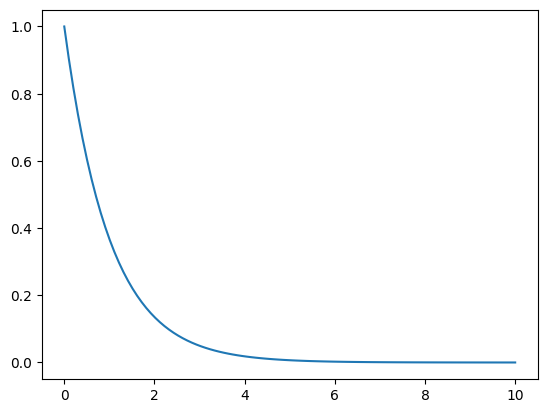

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
lamda = 1
x = np.linspace(0, 10,100)
pdf = (1/lamda) * np.exp(-x/lamda)
plt.plot(x,pdf)
plt.show()

(array([489., 251., 112.,  75.,  39.,  20.,   9.,   2.,   2.,   1.]),
 array([3.69779755e-04, 6.74829085e-01, 1.34928839e+00, 2.02374770e+00,
        2.69820700e+00, 3.37266631e+00, 4.04712561e+00, 4.72158492e+00,
        5.39604422e+00, 6.07050353e+00, 6.74496284e+00]),
 <BarContainer object of 10 artists>)

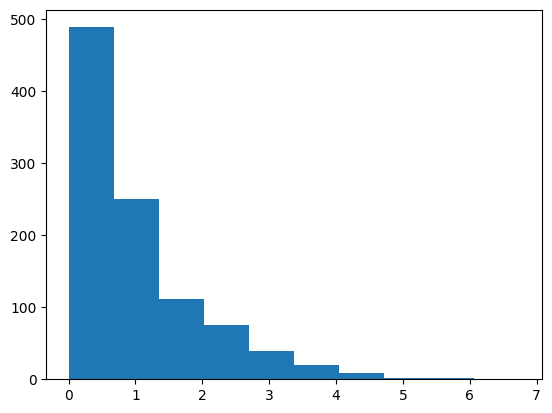

In [ ]:
import matplotlib.pyplot as plt
x = np.random.exponential(1, 1000)
plt.hist(x)

In [ ]:
# x는 한사람이 도착 후, 다음 고객이 도착하는 시간 사이 간격을 의미함
import numpy as np
np.random.seed(seed=1)
x = np.random.exponential(1, 10) # 람다=1인 난수 10개 생성
print(np.mean(x), np.std(x))
entTime = np.cumsum(x) # cummulative summation
print(entTime)

0.43389551257941206 0.35676829778886443
[0.53960584 1.81373109 1.81384547 2.17385823 2.33256782 2.42945169
 2.63556633 3.05954281 3.56499535 4.33895513]


In [ ]:
entTime = 0
while entTime < 720:
    entTime += np.random.exponential(1, 1)[0]
    print(entTime, end=",")

0.5433393706182451,1.6992190803276674,1.9279434878544977,4.032640779062303,4.060410403830726,5.170490730327359,5.710581776771788,6.528589090674825,6.679862010256761,6.900635234373491,8.51380293721384,11.964030146923543,12.340068759832514,13.51877225827564,15.609389231490113,17.859445097462647,17.948324630773552,17.988162508896156,18.17428779417924,20.279190772039765,20.382716121349308,20.929354820874174,24.096813700074378,24.858593713313777,26.035850308213686,26.41493977838337,27.57489865640882,29.37444237583558,29.39289995101115,30.779771738589485,35.27708253529126,36.65606630156706,36.985187214394394,38.54240906846318,38.65136047541388,39.245374839356806,41.637835440794774,41.985429099529306,42.32479098117705,42.464085890565116,42.48364284506903,43.61944477368921,43.85723014012922,44.16585895086885,44.84229289743741,44.89713199192655,45.750724031983516,45.90940161350969,46.799307353244934,48.00247501518811,48.11043271040755,48.64496374673135,49.830442484546076,50.365183941448855,50.4

In [ ]:
import random
random.random()

0.45965311054413394

In [ ]:
# 난수: 난해한 수, 어려운 수, 규칙성이 없는 수
# 0~1 사이 난수

import random
lamda = 1
-lamda * np.log(random.random())

0.17149450752707598

#### 참고: 지수분포 난수를 어떻게 만들 수 있는가?(Inverse Transform Sampling)

* 모든 난수는 U(0,1) 로 부터 만들 수 있다.
* $ X \sim F(x) $ 일때 , $ X = F^{-1}(U), U \sim U(0,1) $ 의 CDF는 F(x)가 성립한다.

$ \hspace{33pt} f(x) = \frac {1}{\lambda} exp(-\frac {x}{\lambda}) $

$$ F(x) = \int_0^x f(x) dx =  \int_0^x \frac {1}{\lambda} exp(-\frac {x}{\lambda}) dx = 1-exp(-\frac {x}{\lambda}) $$

$$ U = 1-exp(-\frac {x}{\lambda}) $$
$$ U = exp(-\frac {x}{\lambda}) $$
$$ ln \ U = -\frac {x}{\lambda} $$

$$ \therefore X = - \lambda \cdot  ln \ U$$
<center><img src="https://drive.google.com/uc?id=1EqPQBYTEyZ5udKYJK4FafgG3wZSmNX0D" width="300" height="200"></center>



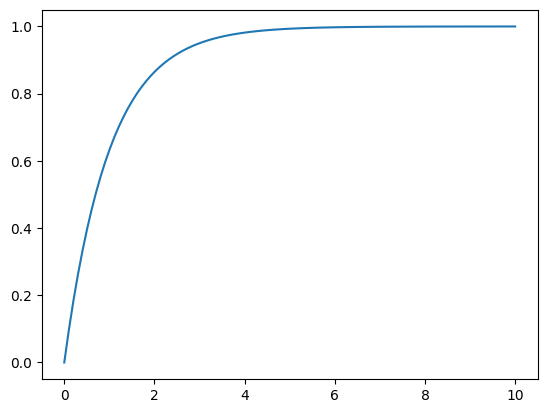

In [ ]:
import matplotlib.pyplot as plt
lamda = 1
x = np.linspace(0, 10,100)
cdf = 1 - np.exp(-x/lamda)
plt.plot(x,cdf)
plt.show()

(array([233., 140., 141.,  97.,  66.,  59.,  62.,  44.,  26.,  27.,  13.,
         23.,  12.,  11.,  12.,   8.,   6.,   2.,   0.,   6.,   3.,   3.,
          1.,   1.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,   1.,   1.]),
 array([1.48058844e-03, 2.18903551e-01, 4.36326513e-01, 6.53749475e-01,
        8.71172438e-01, 1.08859540e+00, 1.30601836e+00, 1.52344132e+00,
        1.74086429e+00, 1.95828725e+00, 2.17571021e+00, 2.39313317e+00,
        2.61055614e+00, 2.82797910e+00, 3.04540206e+00, 3.26282502e+00,
        3.48024798e+00, 3.69767095e+00, 3.91509391e+00, 4.13251687e+00,
        4.34993983e+00, 4.56736280e+00, 4.78478576e+00, 5.00220872e+00,
        5.21963168e+00, 5.43705465e+00, 5.65447761e+00, 5.87190057e+00,
        6.08932353e+00, 6.30674649e+00, 6.52416946e+00, 6.74159242e+00,
        6.95901538e+00, 7.17643834e+00]),
 <BarContainer object of 33 artists>)

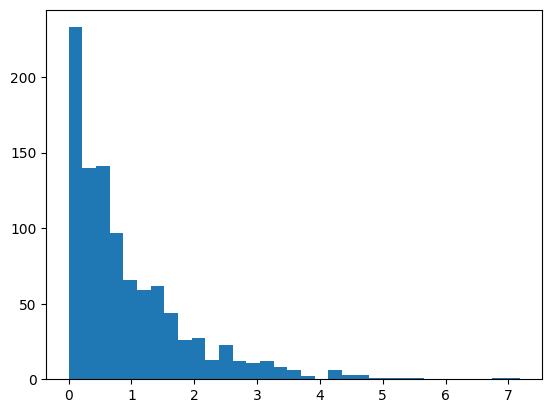

In [ ]:
import numpy as np
u = np.random.random(1000)
lamda = 1
x = -lamda * np.log(u)
plt.hist(x, bins='auto')


* 손님이 도착해서 커피를 주문하고 받는 시간 확률변수 Y라고 하고 $ Y \sim N(1, 0.2^2) $ 이라고 가정하자.
* 그러면 손님이 커피를 가지고 나가는 시간은 아래와 같이 모의실험할 수 있다.

In [ ]:
np.random.seed(seed=1)
cookTime = np.random.normal(1, 0.2, 10)
cookTime = np.where(cookTime < 0, 0,cookTime)
cookTime

array([1.32486907, 0.87764872, 0.89436565, 0.78540628, 1.17308153,
       0.53969226, 1.34896235, 0.84775862, 1.06380782, 0.95012592])

In [ ]:
np.mean(cookTime)

0.9805718218387799

In [ ]:
np.std(cookTime)

0.23817971041278044

* 아래는 큐 대기인원을 계산한 예다. 이 예에서는 CookTime = 1분으로 고정했다.

<center><img src="https://drive.google.com/uc?id=1BRqUT8geULTRVMw6uYsId7B3kvFvLoj4" width="400" height="250"></center>

<font color='red'>H.W # 6: 위의 예처럼 오전 8시에 시작해서 오후 10시에 종료하는 커피가게 큐 대기인원의 분포를 모의실험하시오.</font>
* 큐에 최대 인원은 몇 명인가?
* 시간대 별로 도착시간 분포를 조정해 보세요 즉, 점심시간에는 사람이 붐비게 해 봅시다.
* 주문을 두명이 받는다면 어떻게 되는가?

Hint>
* Cust Class를 만들고, arriveTime, orderTime, outTime을 관리한다.
* Shop Class를 만들고, custQueue를 만든다.
  * getSize method: 큐 크기를 구한다.
  * entCust method: 큐에 cust를 넣는다.
  * outCust method: 큐에서 cust를 내보낸다.(조건은 현재 시간보다 outTime이 작은 cust는 deQueue 한다.)
  * getLast method: 큐에 가장 최근에 들어간 고객을 리턴한다.
  
* main 프로그램
  * 커피가게를 만든다.
  * curTime = 0 (8시) 부터 14\*60 분 보다 작을 때까지 아래를 반복한다.
  * 고객을 생성한다.  (도착시간 정의)
  * 큐에 고객이 없으면 현재 고객의 orderTime = arriveTime이고 고객이 있으면 최근에 들어간 고객의 outTime 이다.
  *  outTime = orderTime + cookTime
  * 고객을 큐에 넣는다.
  * curTime을 현재 고객의 arriveTime으로 한다.
  * 큐에서 curTime 보다 outTime이 과거인 고객은 deQueue한다.

### DeQueue(Double Ended Queue)
* 큐는 좌측에서 입력하고 우측에서 출력하는데 DeQueue는 양쪽에서 입력과 출력이 가능하다.
* 윈도우의 스크롤에서 덱을 사용하면 효율적이다.

<center><img src="https://drive.google.com/uc?id=12ARtoAaUIsV4Z76x-WV6k_5AOgZjIOZB" width="500" height="300"></center>


In [ ]:
class Dequeue:
    def __init__(self):
        self.dq = []

    def insertFirst(self, item):
        self.dq.insert(0, item)

    def insertLast(self, item):
        self.dq.append(item)

    def isEmpty(self):
        if len(self.dq) > 0:
            return False
        else:
            return True

    def popFirst(self):
        return self.dq.pop(0)

    def popLast(self):
        return self.dq.pop(-1)

    def peekFirst(self):
        return self.dq[0]

    def peekLast(self):
        return self.dq[-1]

    def print(self):
        print(self.dq)

    def sum(self):
        return sum(self.dq)

a = Dequeue()
a.insertFirst(2)
a.insertFirst(1)
a.insertLast(3)
a.insertLast(4)
a.print()
print(a.sum())

print(a.popFirst())
print(a.popLast())
a.print()

[1, 2, 3, 4]
10
1
4
[2, 3]
